# Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# noinspection PyPackageRequirements
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import normaltest, anderson
from scipy.stats import shapiro
from scipy.stats import spearmanr
import os
import shutil
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from scipy.stats import levene
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder
from sklearn.feature_selection import mutual_info_regression 
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression 

# Load datasets

In [1]:
import sys
print(sys.executable)

/home/istvan/zneus_1/venv/bin/python3


In [2]:
# Load datasets
df1 = pd.read_csv("observations.tsv", sep='\t')
df2 = pd.read_csv("patients.tsv", sep='\t')
df3 = pd.read_csv("stations.tsv", sep='\t')

In [3]:
df1.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude']

In [4]:
df2.columns.tolist()

['address',
 'job',
 'company',
 'blood_group',
 'ssn',
 'station_ID',
 'current_latitude',
 'current_longitude']

In [5]:
df3.columns.tolist()

['longitude', 'latitude', 'code', 'station', 'location']

In [6]:
result = df2.groupby('station_ID')['blood_group'].value_counts()
print(result)

station_ID  blood_group
0           AB+            1
1           A-             2
            A+             1
            AB+            1
            AB-            1
                          ..
804         AB+            1
            B-             1
805         A-             1
            B-             1
            O+             1
Name: count, Length: 1772, dtype: int64


We are going to join observations with stations because:
    - both dataset contain latitude + longtitude and we know that it can be mapped one to another
    - station, code, location may represent different equipment, staff, these may influence the measuremtns

We are not merging df2 with observations because:
    - There is no common identifier
    - The only possible link is bet stations and it would bring errors
    - Label noise if we incorrectly link patient with observation
    - Aggregating patient attributes per station is not useful because attributes blood_group, job, company, address are individual specific, not station-level

# Merging df1 with df3

In [7]:
keys = ['longitude', 'latitude']
df = pd.merge(df1, df3, on=keys, how='inner')

In [8]:
df.shape

(12072, 26)

Did not lose any records, attributes added only.
Our target is oximetry.
We have numeric features and categorical features.

In [9]:
df.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude',
 'code',
 'station',
 'location']

In [10]:
df['location'].nunique()

140

In [11]:
df['code'].nunique()

107

In [12]:
df['station'].nunique()

552

Location is high-cardinality categorical - one hot encoding would increase dimensionality and it would hurt our model, no meaningful geographical location, we already have latitude and longitude

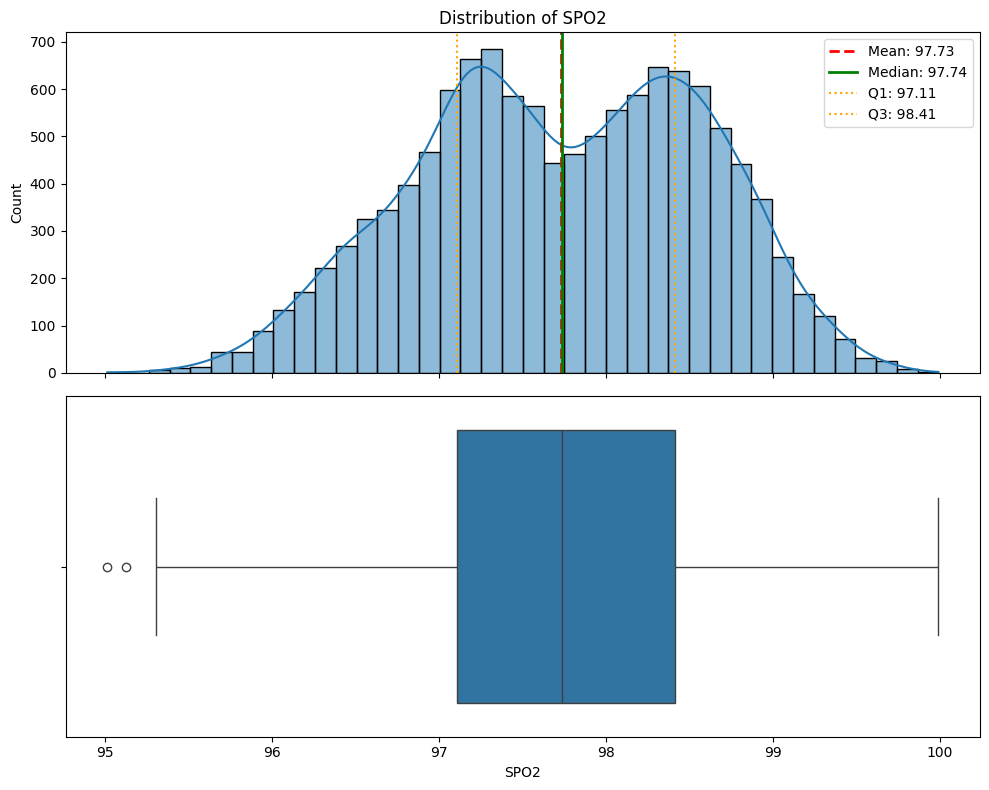


--- SPO2 ---
Probably not normal
------------------------------------------------------------


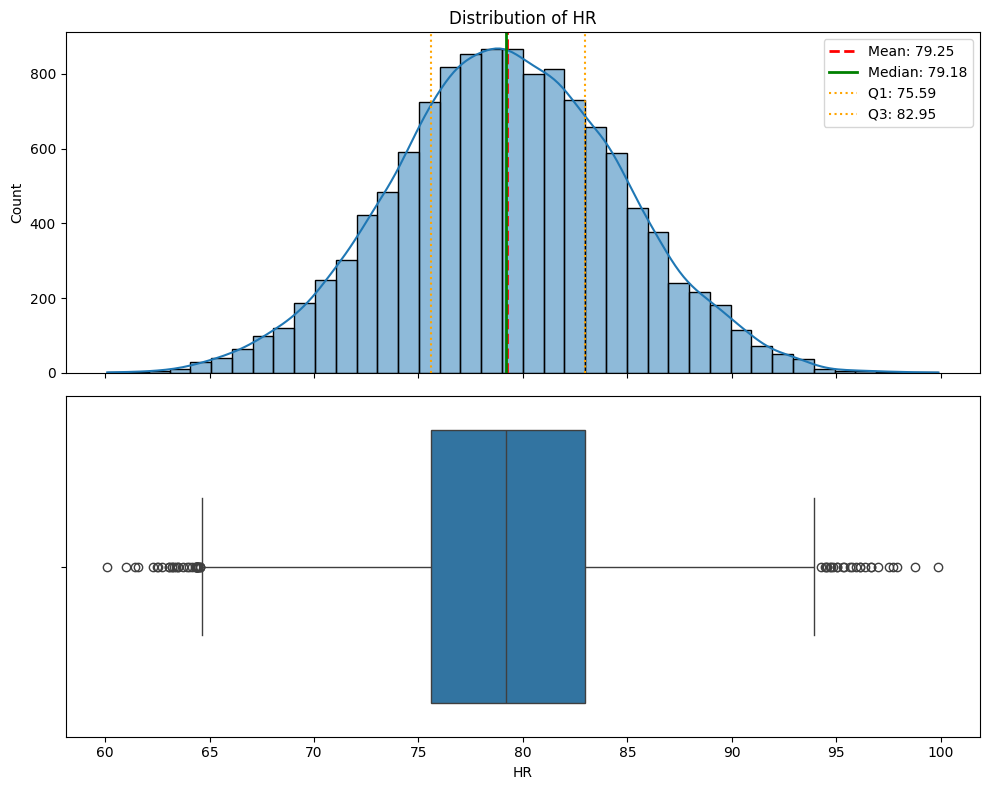


--- HR ---
Probably normal
------------------------------------------------------------


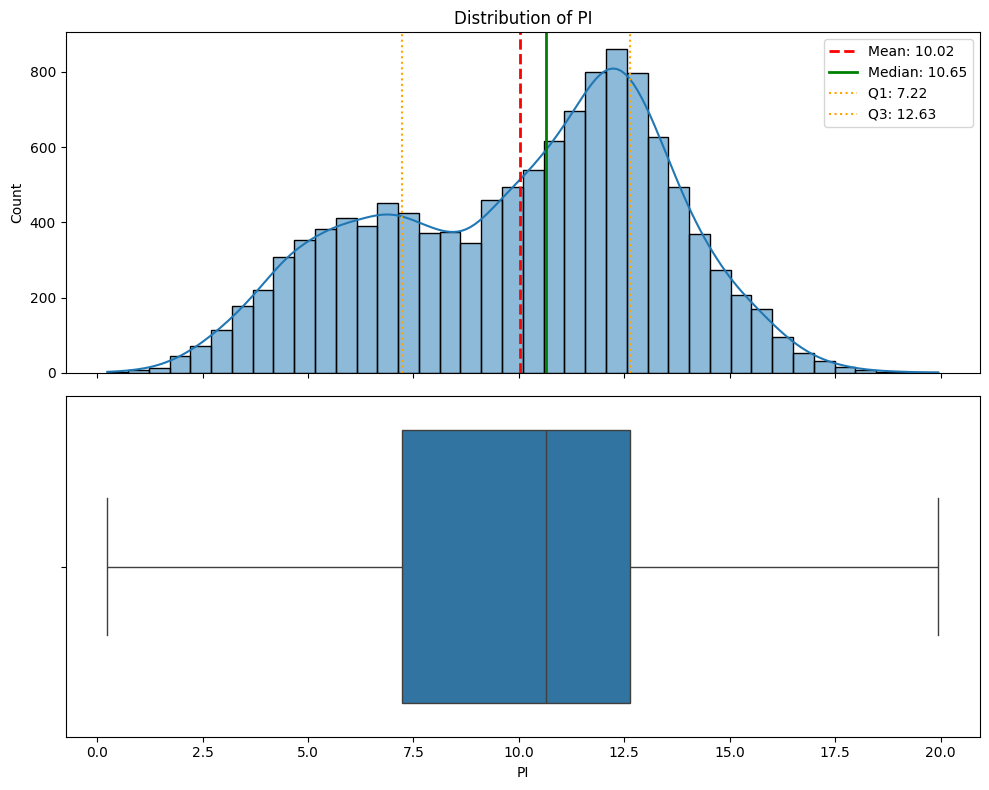


--- PI ---
Probably not normal
------------------------------------------------------------


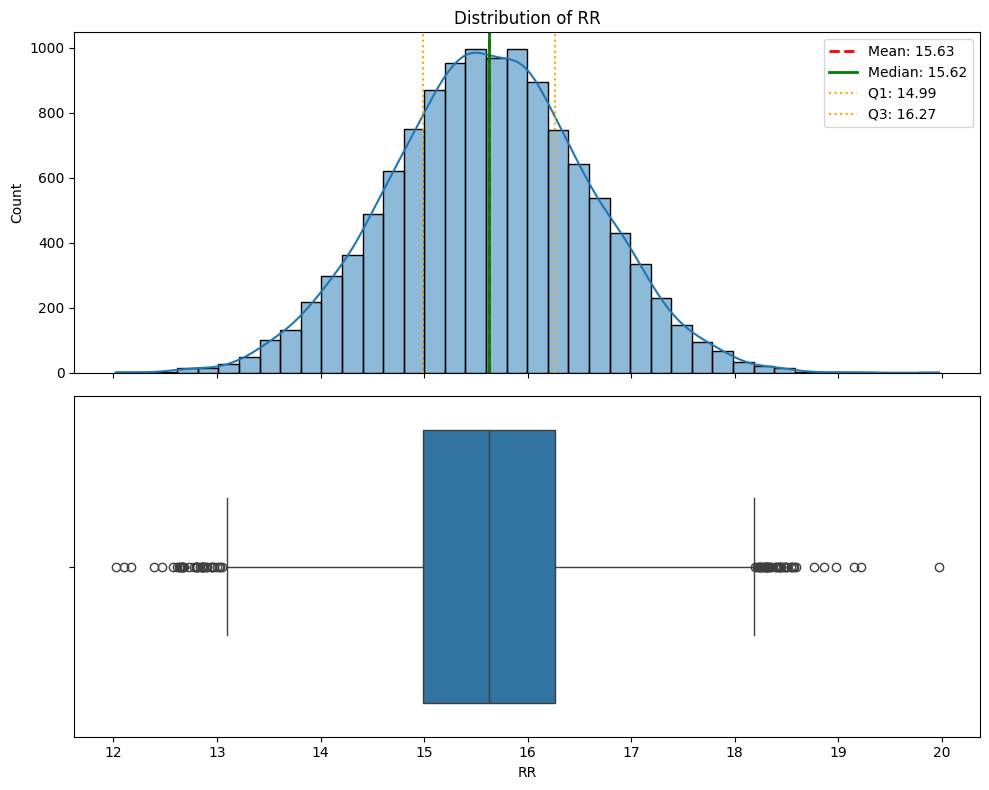


--- RR ---
Probably normal
------------------------------------------------------------


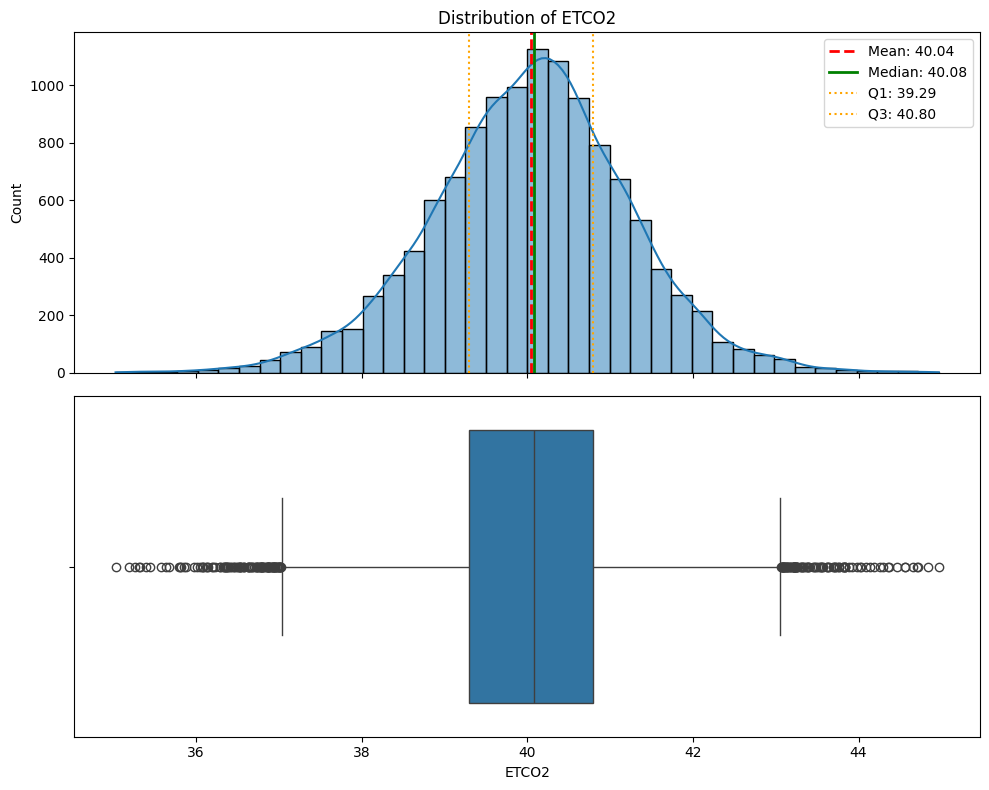


--- ETCO2 ---
Probably not normal
------------------------------------------------------------


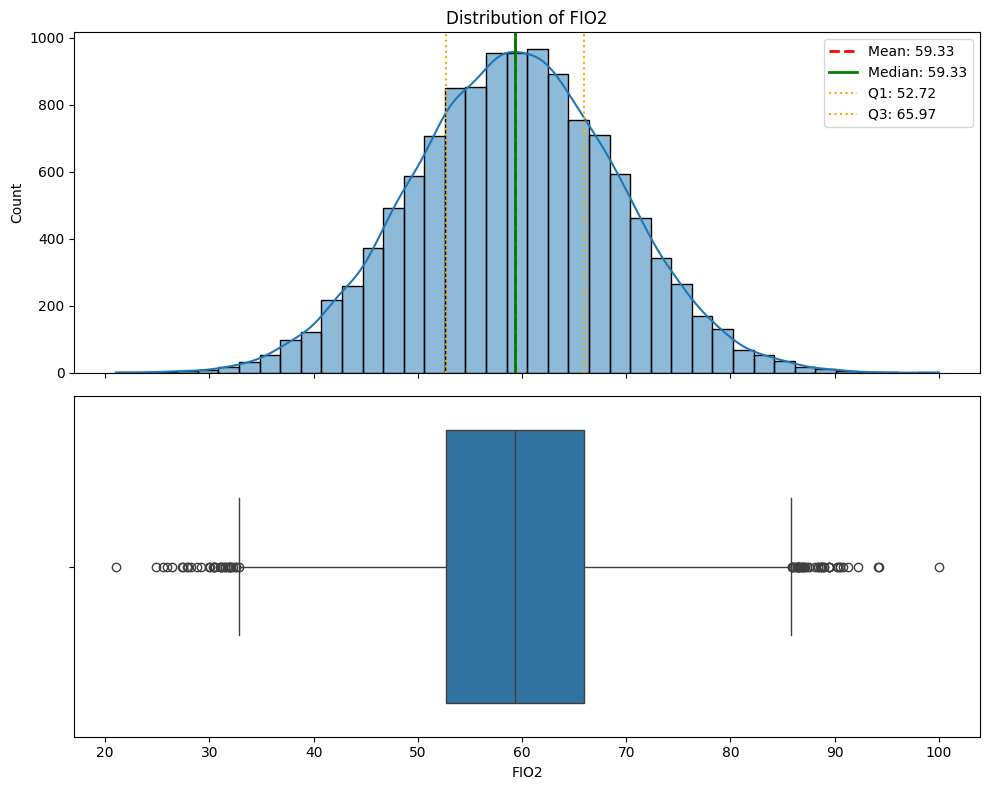


--- FIO2 ---
Probably normal
------------------------------------------------------------


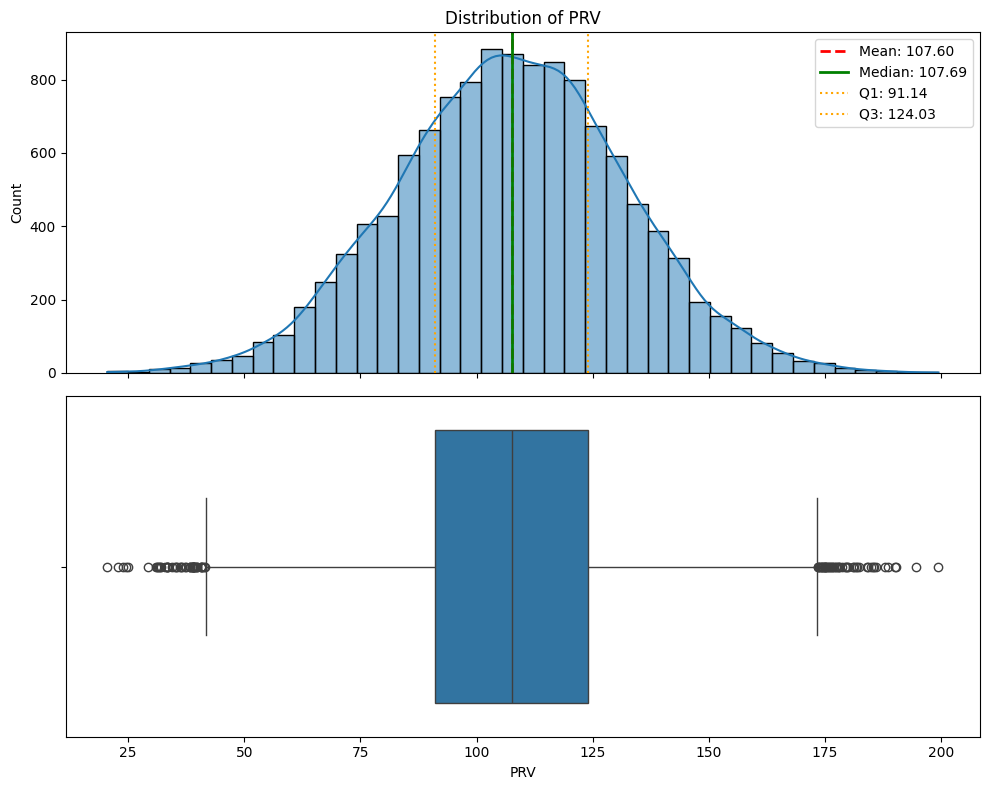


--- PRV ---
Probably normal
------------------------------------------------------------


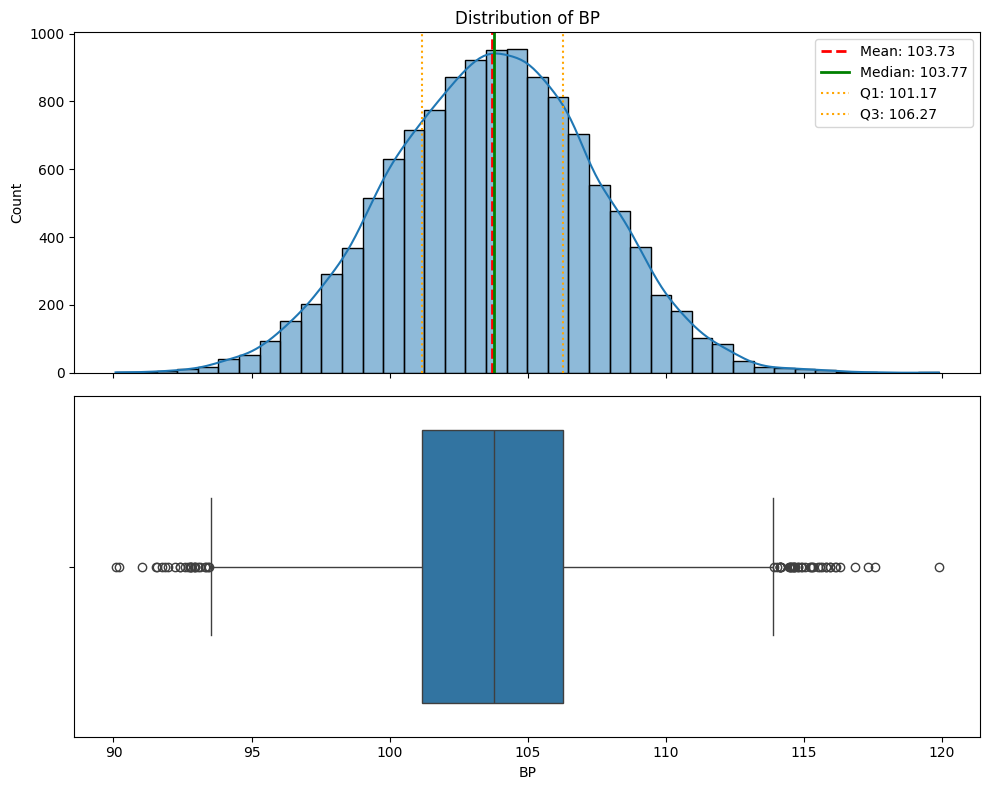


--- BP ---
Probably normal
------------------------------------------------------------


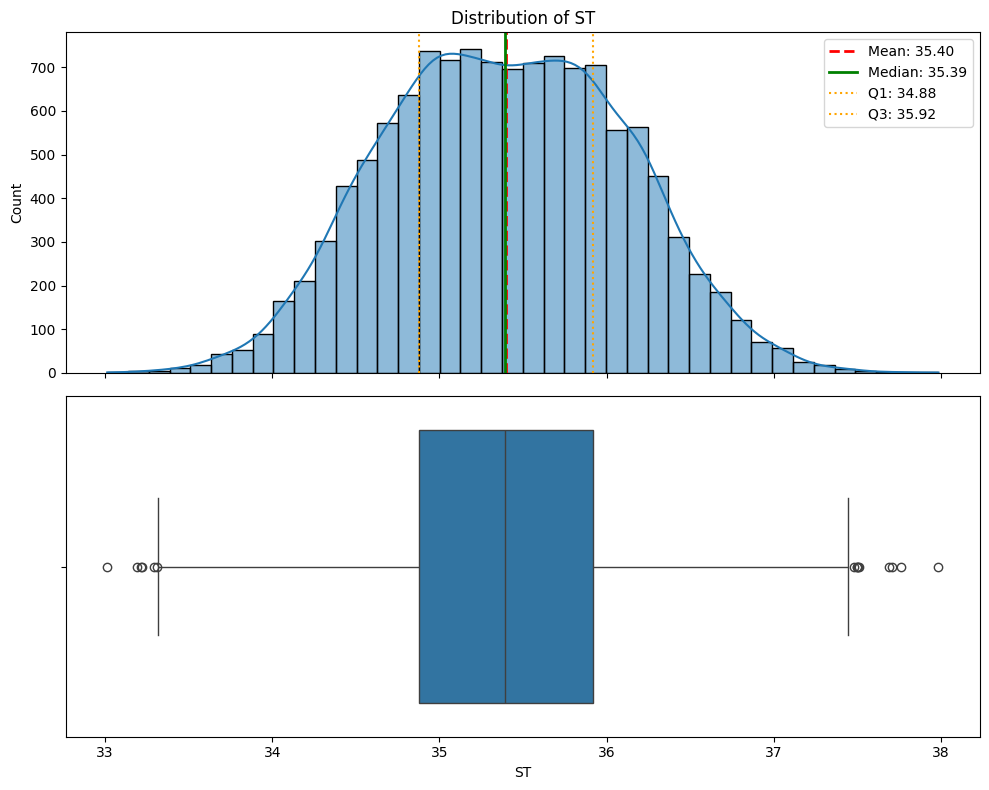


--- ST ---
Probably not normal
------------------------------------------------------------


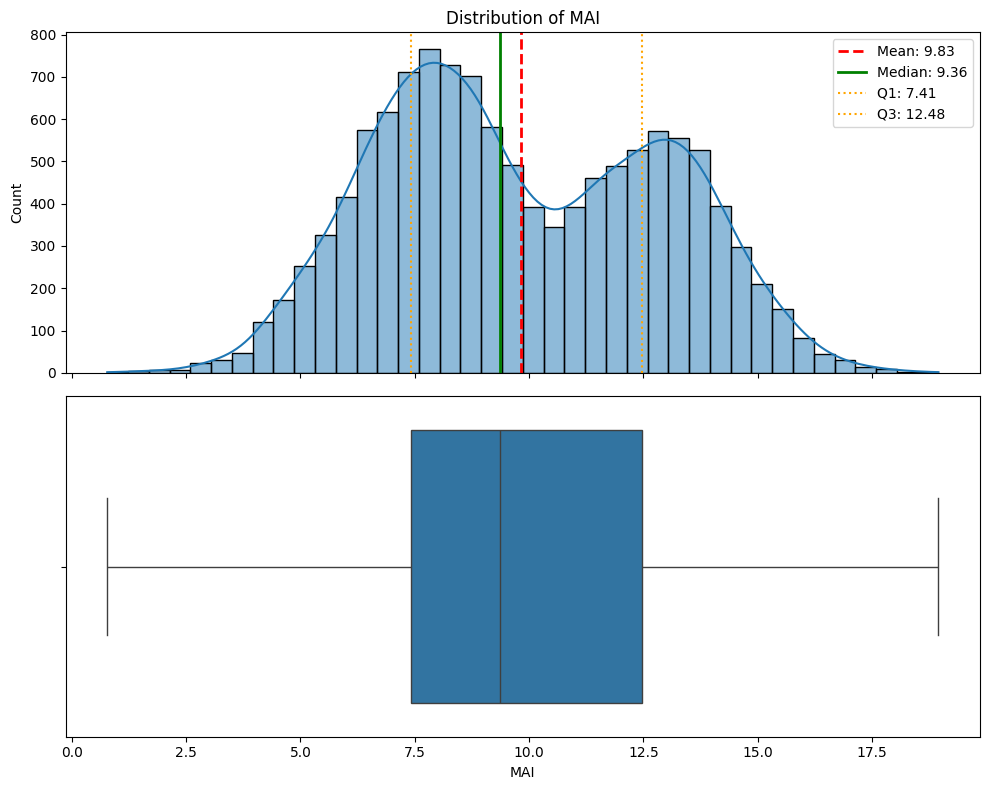


--- MAI ---
Probably not normal
------------------------------------------------------------


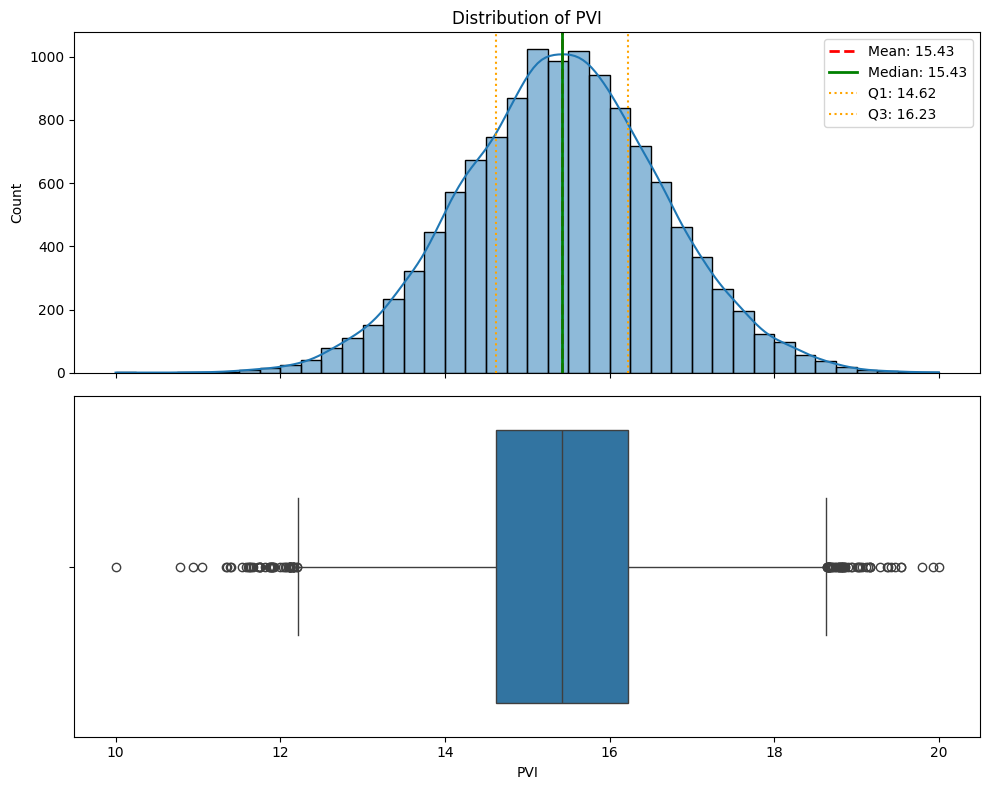


--- PVI ---
Probably normal
------------------------------------------------------------


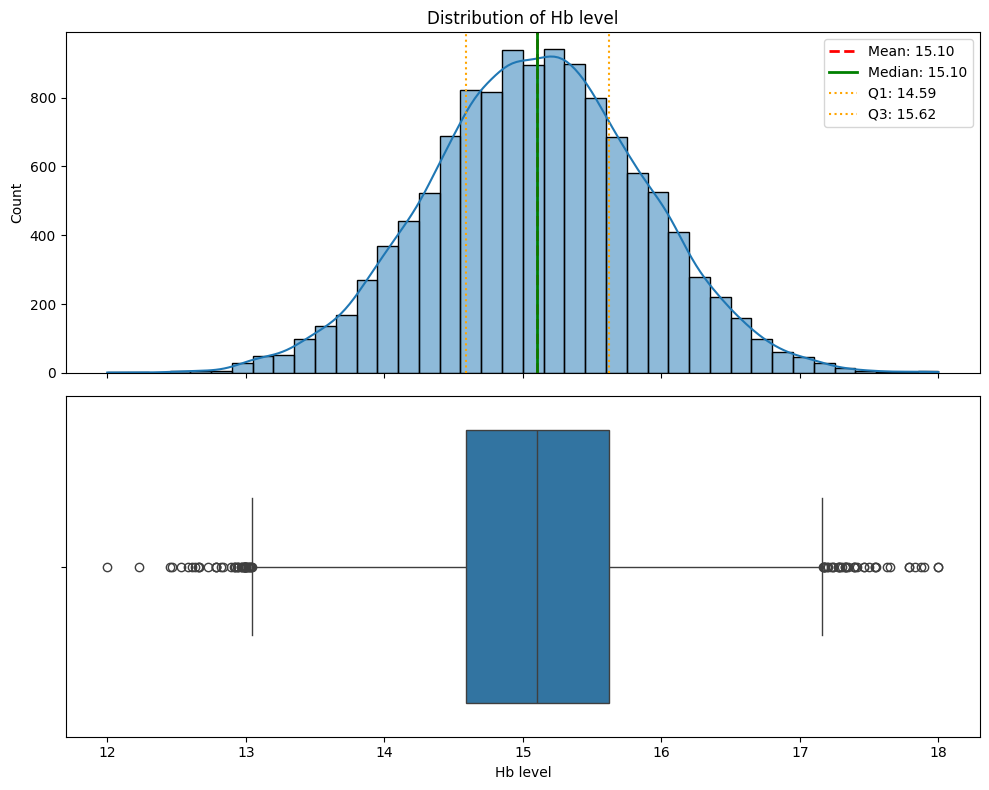


--- Hb level ---
Probably normal
------------------------------------------------------------


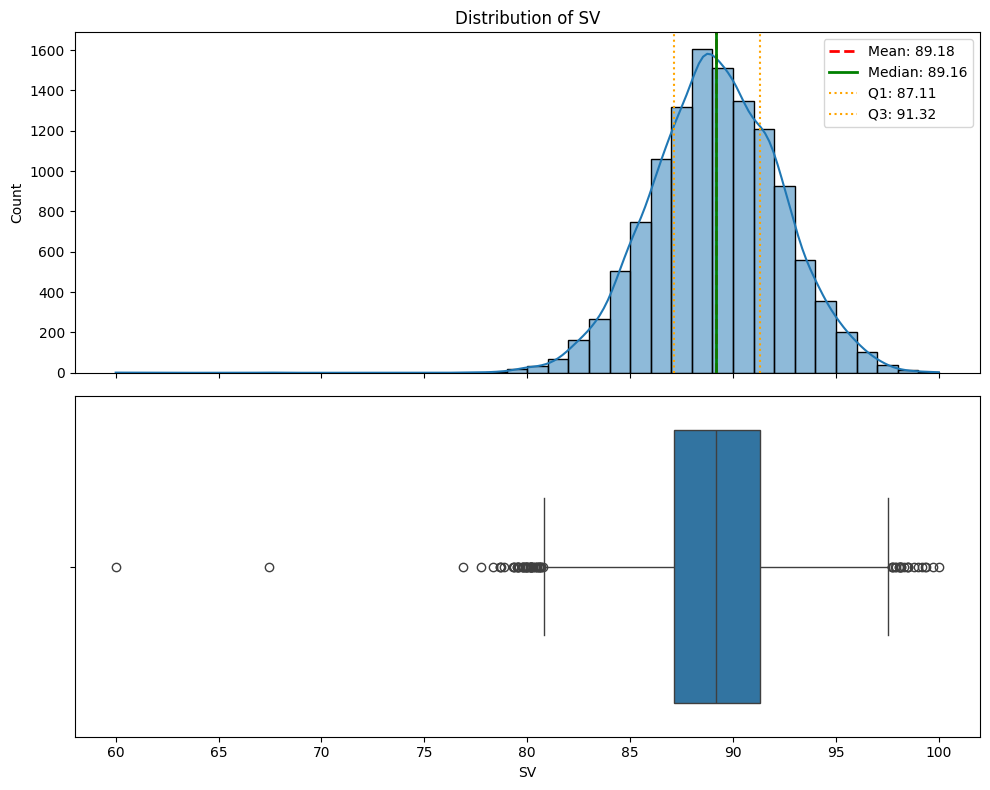


--- SV ---
Probably not normal
------------------------------------------------------------


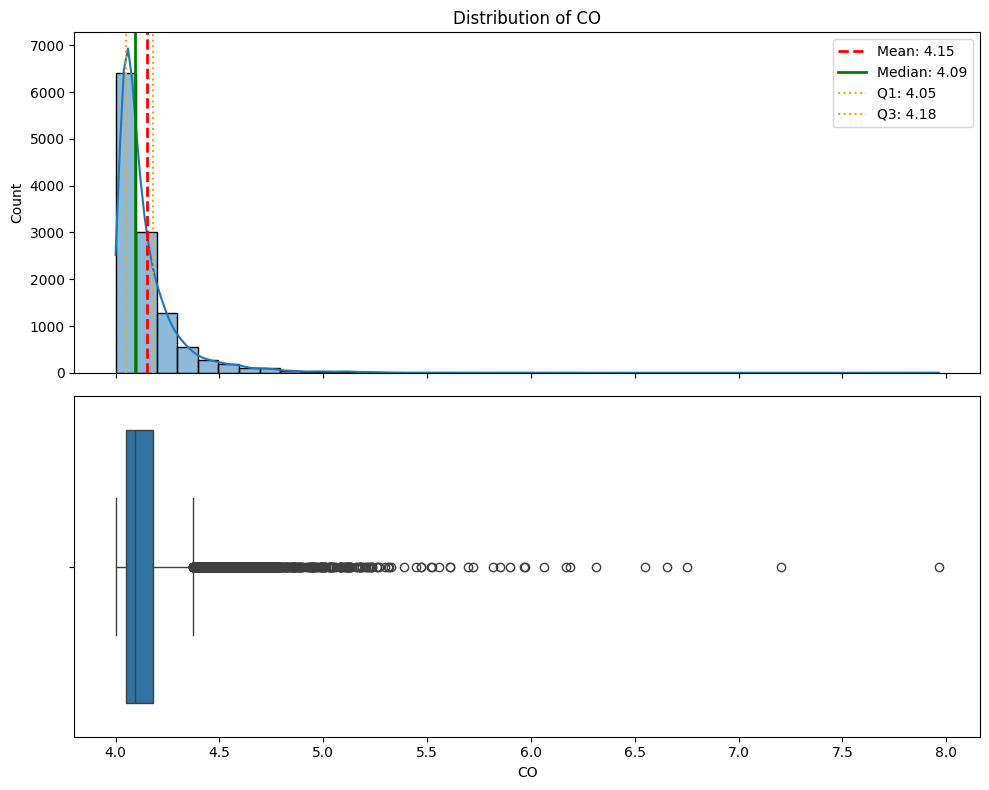


--- CO ---
Probably not normal
------------------------------------------------------------


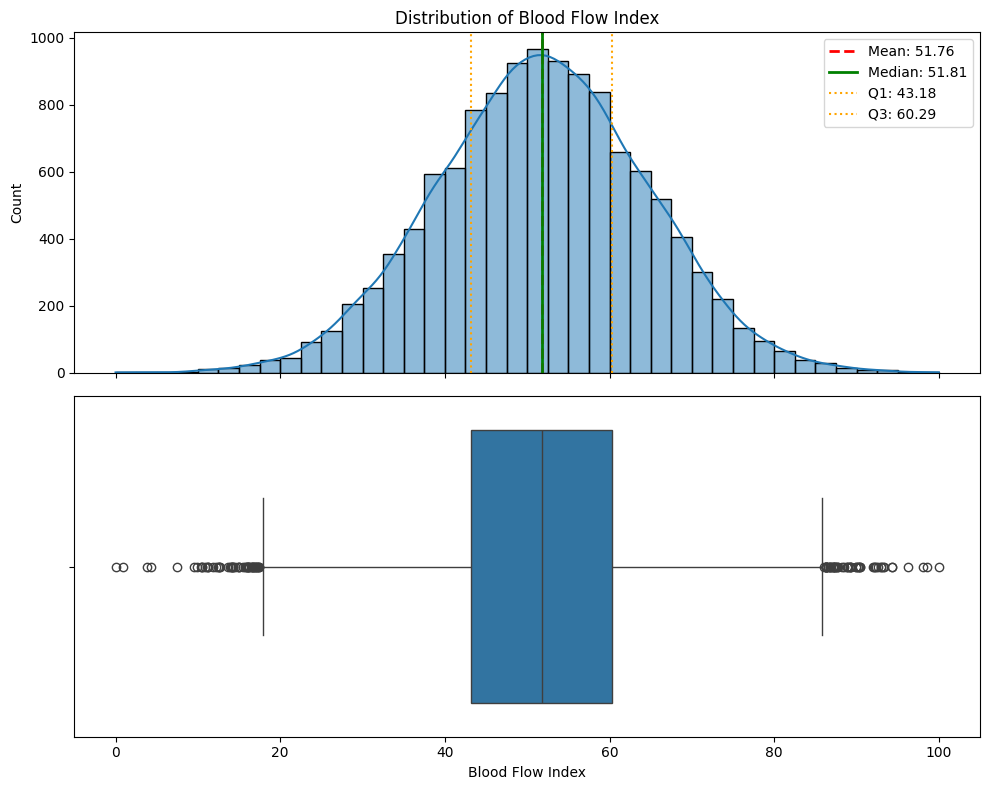


--- Blood Flow Index ---
Probably normal
------------------------------------------------------------


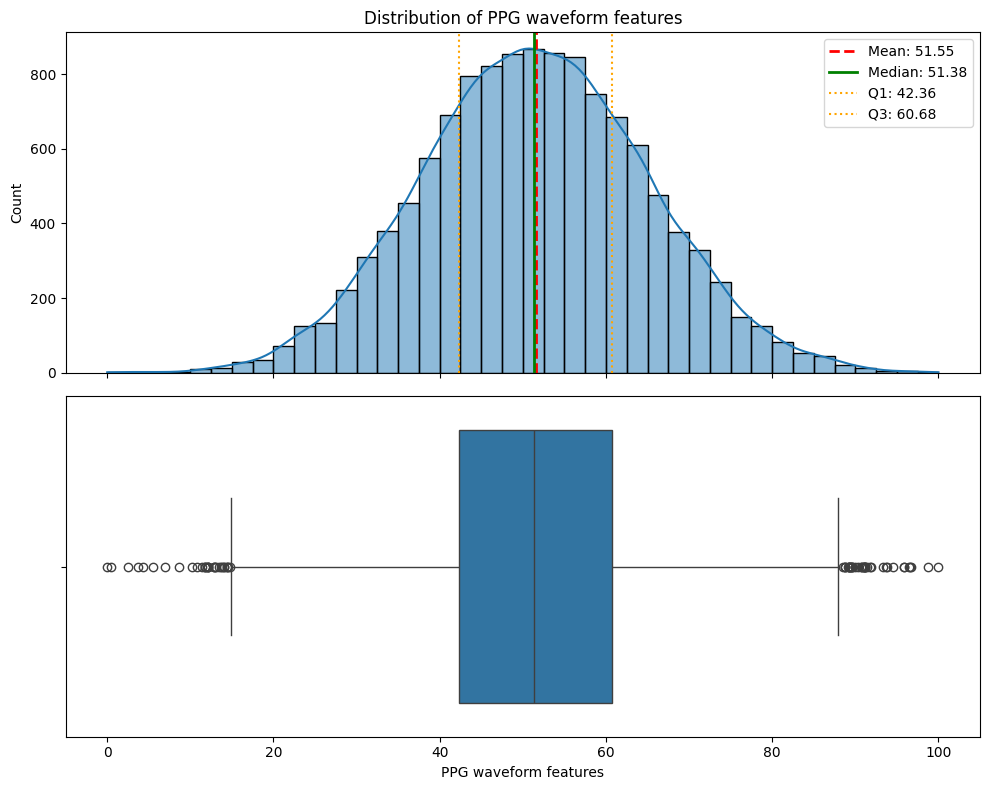


--- PPG waveform features ---
Probably normal
------------------------------------------------------------


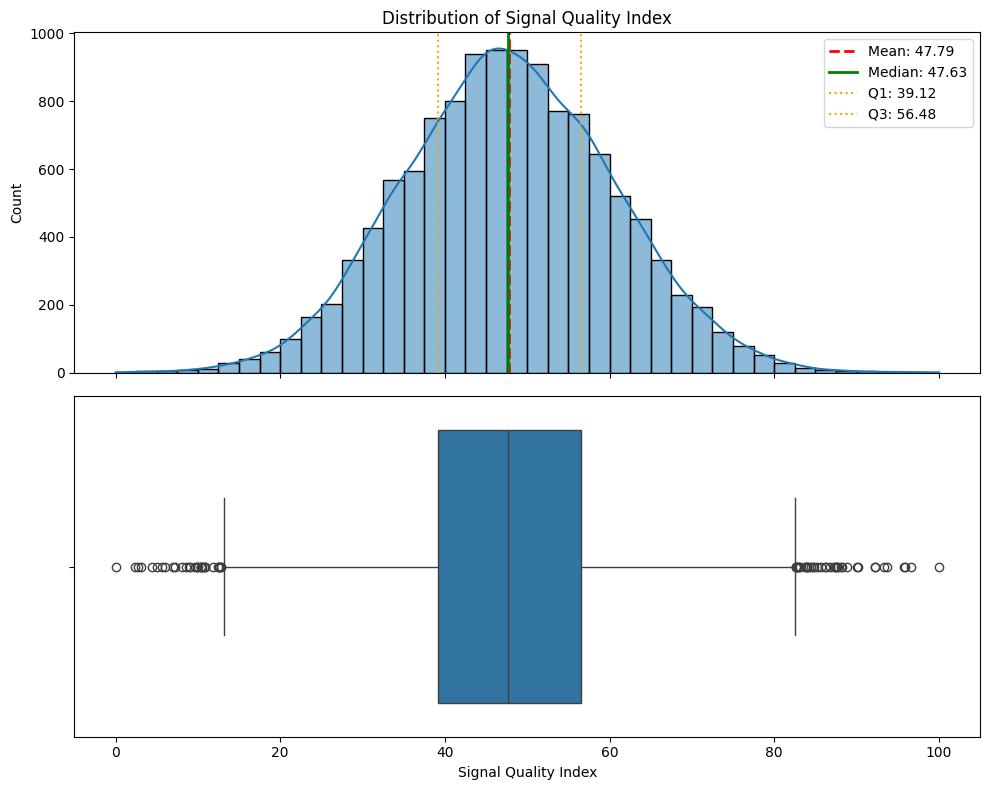


--- Signal Quality Index ---
Probably normal
------------------------------------------------------------


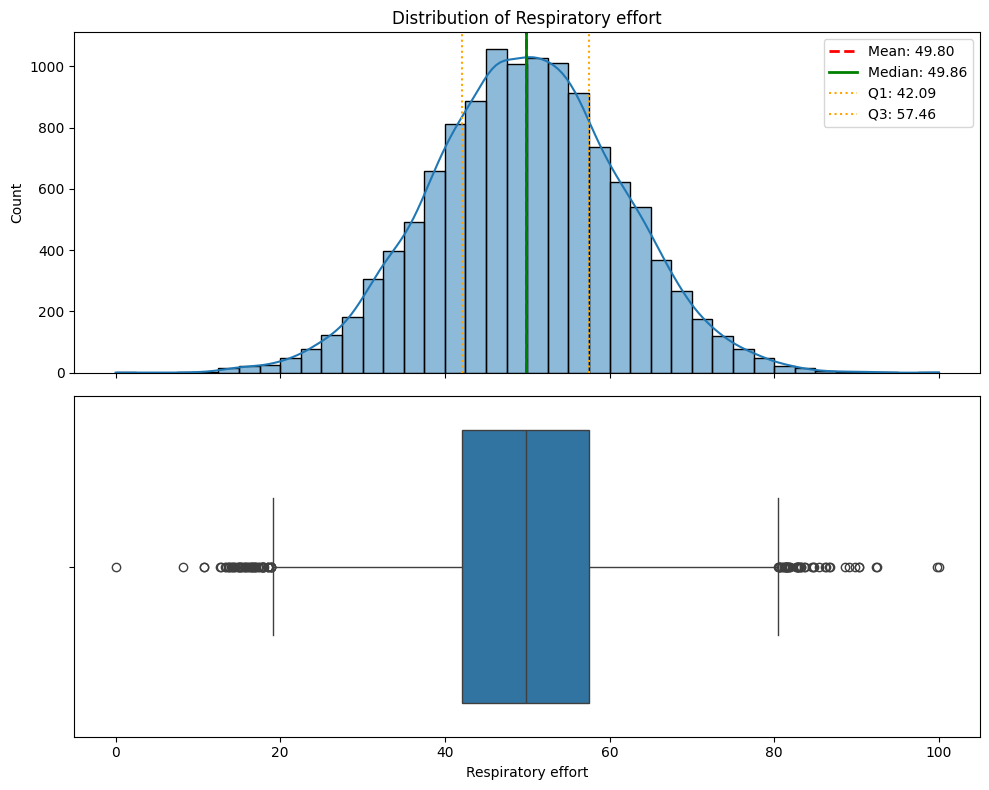


--- Respiratory effort ---
Probably normal
------------------------------------------------------------


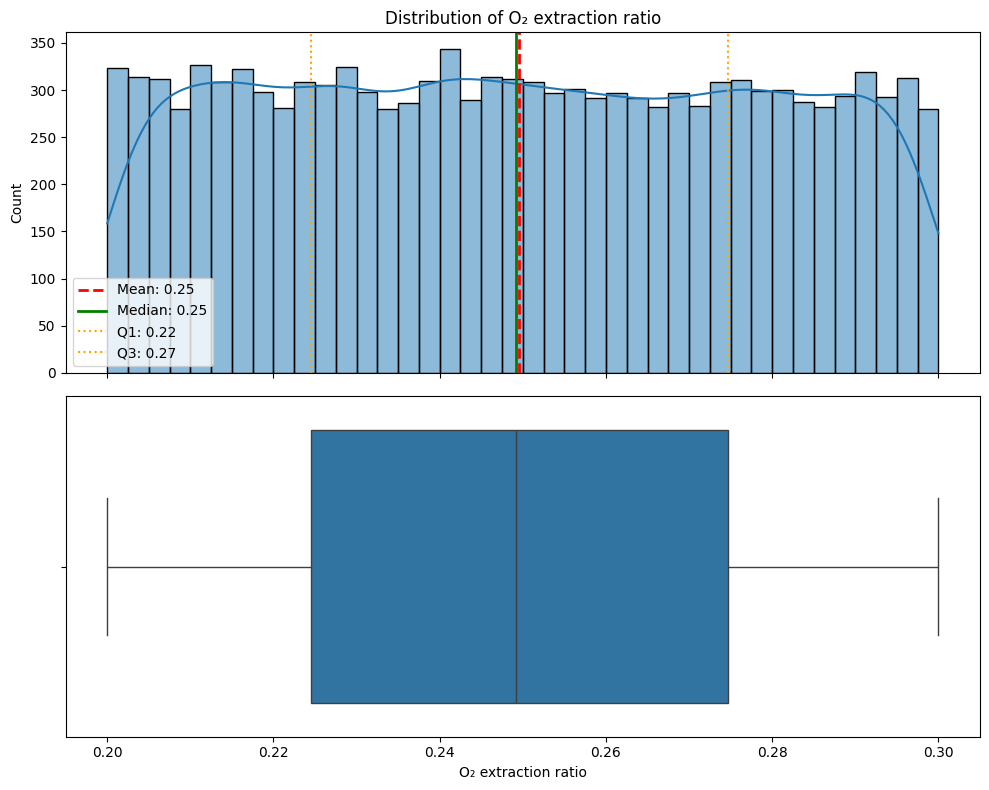


--- O₂ extraction ratio ---
Probably not normal
------------------------------------------------------------


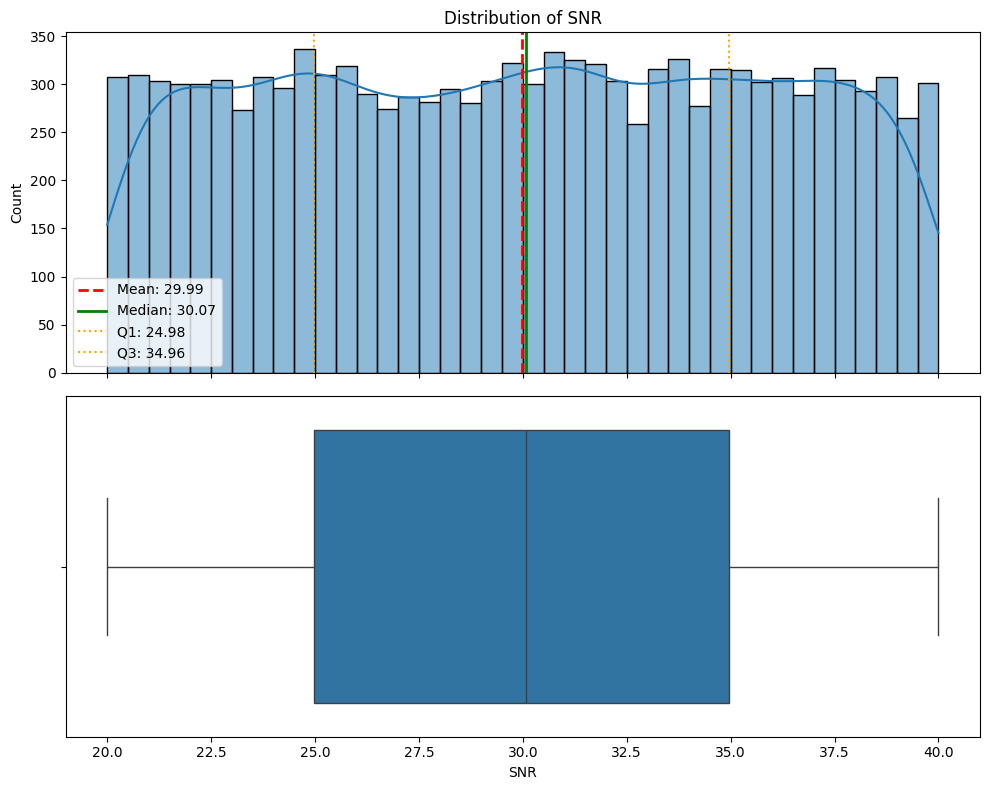


--- SNR ---
Probably not normal
------------------------------------------------------------


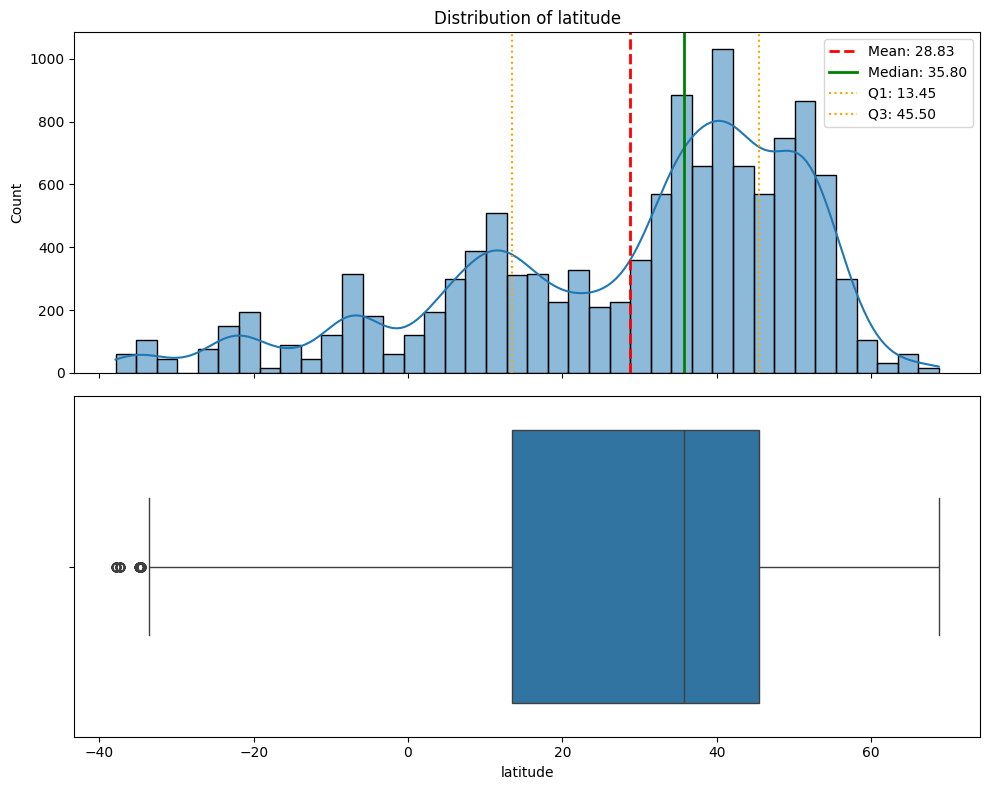


--- latitude ---
Probably not normal
------------------------------------------------------------


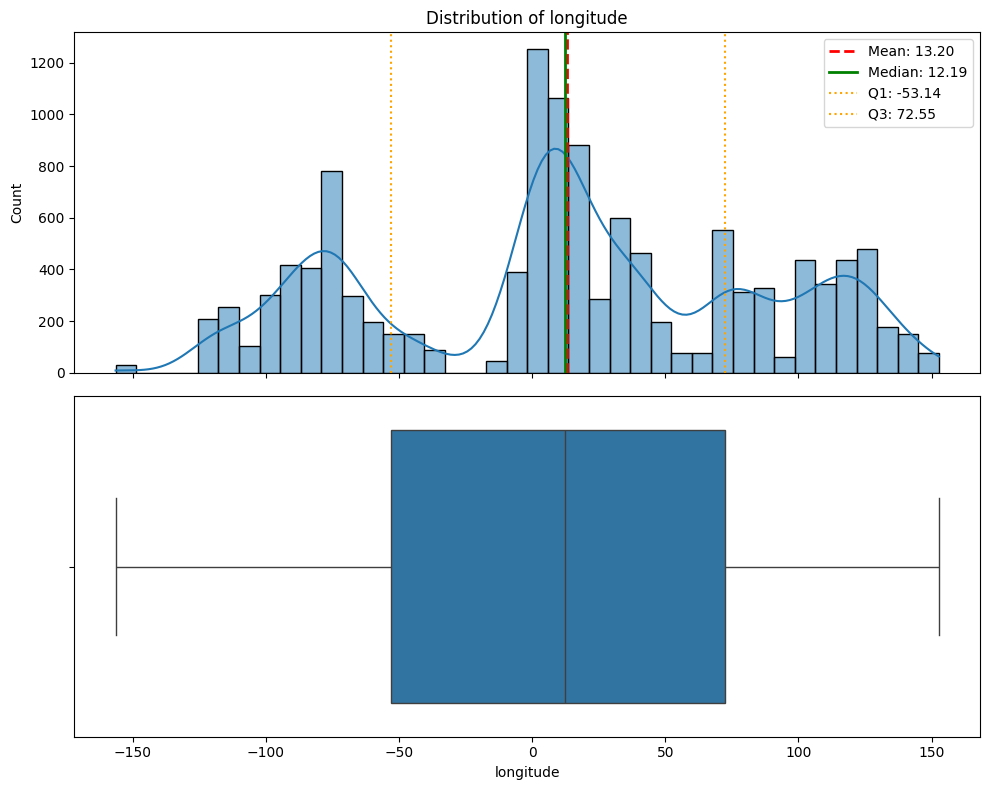


--- longitude ---
Probably not normal
------------------------------------------------------------


In [13]:
numeric_cols = [
    'SPO2',
    'HR',
    'PI',
    'RR',
    'ETCO2',
    'FIO2',
    'PRV',
    'BP',
    'ST',
    'MAI',
    'PVI',
    'Hb level',
    'SV',
    'CO',
    'Blood Flow Index',
    'PPG waveform features',
    'Signal Quality Index',
    'Respiratory effort',
    'O₂ extraction ratio',
    'SNR',
    'latitude','longitude']
    

for col in numeric_cols:
    # Create figure with 2 subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Top plot: Histogram with KDE
    sns.histplot(df[col], bins=40, kde=True, ax=ax1)
    
    # Calculate statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    # Add vertical lines for mean, median, Q1, Q3 on histogram
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.axvline(q1, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q1:.2f}')
    ax1.axvline(q3, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q3:.2f}')
    ax1.set_title(f'Distribution of {col}')
    ax1.legend()
    
    # Bottom plot: Boxplot (horizontal)
    sns.boxplot(x=df[col], ax=ax2)
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n--- {col} ---")
    
    # Normality test
    stat, p = normaltest(df[col].dropna())
    if p > 0.05:
        print("Probably normal")
    else:
        print("Probably not normal")
    print("-" * 60)

In [14]:
TARGET = 'oximetry'

STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort',
    'O₂ extraction ratio','SNR'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

DROP_COLS = [
    'location'
]

In [15]:
df['code'].isnull().sum()

np.int64(15)

From phase 1 we know that one station has no code, we are going to fill these 15 observations with most frequent code in this dataset. which might have changed because we merged it with observations and that could transfer another code as most frequent if that region has many observations..

In [16]:
most_frequent_value = df['code'].mode().iloc[0]
print(most_frequent_value)

US


US is the most frequent one

In [17]:
df['code'] = df['code'].fillna(most_frequent_value)

In [18]:
df['code'].isnull().sum()

np.int64(0)

# Now we divide data into train and test

In [19]:
(df['oximetry'] == 0).sum()

np.int64(4908)

In [20]:
(df['oximetry'] == 1).sum()

np.int64(7164)

The data are moderetaly imbalanced 40 : 60

In [21]:
X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

Training size: (8450, 24), Test size: (3622, 24)


Before splitting the dataset, we checked the distribution of the target variable (oximetry). The dataset contains 4908 samples of class 0 (40%) and 7164 samples of class 1 (60%). Since the dataset is moderately imbalanced, we used train_test_split with the stratify parameter to ensure that both training and test sets maintain the same class proportions.

# PIPELINES FOR EACH COLUMN GROUP

In [22]:
standard_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

power_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),  # handles zeros/negatives
    ("scaler", StandardScaler())
])

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])

# FULL COLUMN TRANSFORMER

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

# FIT TRANSFORM ON TRAINING DATA

In [24]:
preprocessor.fit(X_train, y_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [25]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)
print("Processed type:", type(X_train_processed))

Processed X_train shape: (8450, 130)
Processed X_test shape: (3622, 130)
Processed type: <class 'scipy.sparse._csr.csr_matrix'>


We categorized the numeric features into standard, robust, and skewed groups and applied StandardScaler, RobustScaler, and PowerTransformer accordingly. This avoids over-scaling outliers and helps normalize heavily skewed variables. 

The data was split 70:30 before preprocessing to prevent leakage, and categorical variables were handled differently based on cardinality: one-hot encoding for low-cardinality features and leave-one-out encoding for high-cardinality ones. 

If model performance is insufficient, one possible improvement is to replace one-hot encoding, since creating 107 binary features may lead to sparsity and suboptimal feature selection.

# Feature extraction

In [26]:
X_processed_dense = X_train_processed.toarray()
df_processed = pd.DataFrame(X_processed_dense)

In [27]:
df_processed.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,129
0,-0.686370,1.384600,0.723559,-0.761383,0.284614,-0.348849,-3.435389,-0.267175,0.752194,-1.863581,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.400000
1,-1.618033,-1.067971,0.409284,1.255385,-0.712865,0.105777,-1.354397,-0.116577,0.781469,0.960042,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.692308
2,0.212331,-2.227959,1.412075,-0.397716,-1.261274,-1.113976,-1.724441,-1.340296,-0.549094,0.887992,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.619048
3,0.410884,-0.955209,2.484921,0.439640,1.577221,-0.474930,-0.108385,-1.992174,1.211299,1.594467,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.720000
4,0.077551,-0.909751,-1.138266,1.095678,1.904119,-1.226862,-0.373540,1.579750,-1.502019,-1.609493,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.909091


To select right features for our data model it needs to be done with one of these techniques: applying features, doing wrapper and embedding

# Filters

### Variance treshold 
is a simple method to find predict whether the variable is going to effect the predicted value. If the variable has low variance we can predict that the variable will not effect predicted value since constant variables will make the same effect. 

Since we used standard scaler on some part of data, the Variance treshold filter will not tell us valid information since variance of these data will be always 1.

See below the first +-20 features:

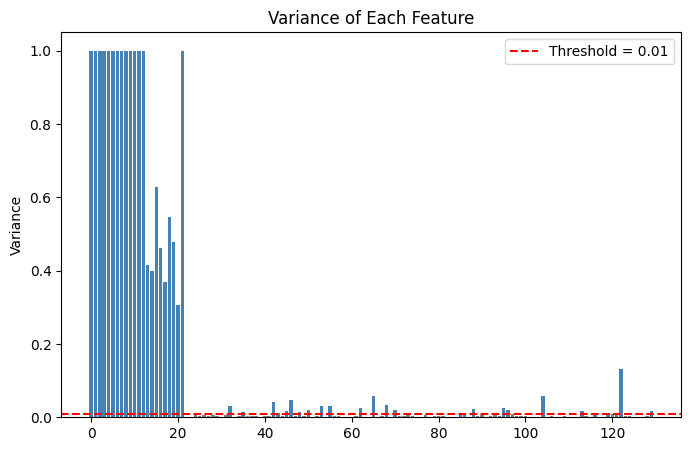

In [28]:
selector = VarianceThreshold(0.2)
selector.fit(df_processed, y_train)
variances = df_processed.var()
treshold = 0.01

plt.figure(figsize=(8, 5))
plt.bar(variances.index, variances.values, color=['gray' if val < treshold else 'steelblue'  for val in variances])
plt.axhline(y=treshold, color='red', linestyle='--', label=f'Threshold = {treshold}')
plt.title('Variance of Each Feature')
plt.ylabel('Variance')
plt.legend()
plt.show()

### Mutual information

Mutual Information is a great way to detect relationships in the data. It is based on the concept of Information Entropy and has the advantage of revealing even non-linear dependencies between features and the target variable

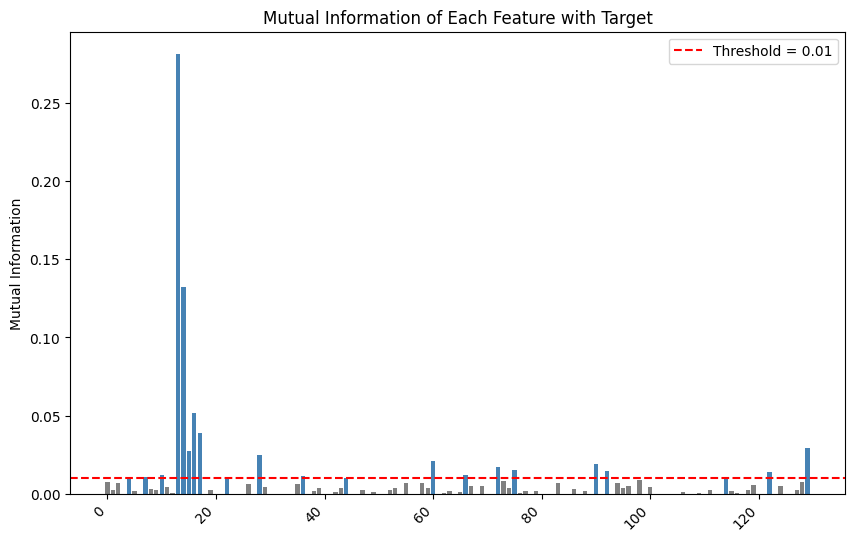

In [48]:
mi = mutual_info_regression(df_processed, y_train)  
mi_series = pd.Series(mi, index=df_processed.columns)

threshold = 0.01
colors = ['gray' if val < threshold else 'steelblue' for val in mi_series]

plt.figure(figsize=(10,6))
plt.bar(mi_series.index, mi_series.values, color=colors)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.xticks(rotation=45, ha='right')
plt.title('Mutual Information of Each Feature with Target')
plt.ylabel('Mutual Information')
plt.legend()
plt.show()

In [70]:
top_features = mi_series.sort_values(ascending=False).head(2)
for feature, value in top_features.items():
    print(f"{feature}: {value:.4f}")

13: 0.2815
14: 0.1319


To see smaller values more clearly, we can cut the most significant outliers

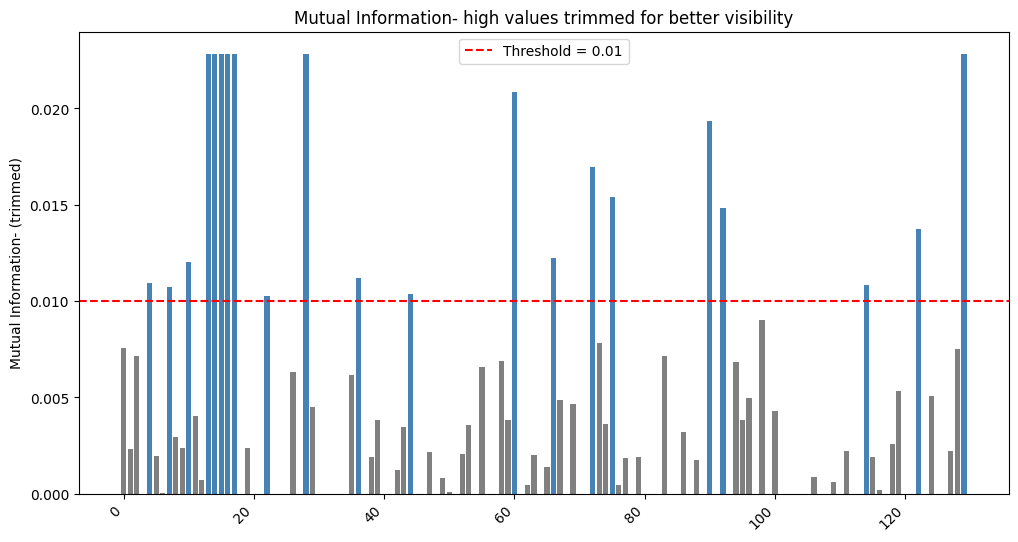

In [49]:
max_display = np.percentile(mi_series.values, 95)  # cut top 5 % of the highest
plt.figure(figsize=(12,6))
plt.bar(mi_series.index, np.clip(mi_series.values, 0, max_display), color=colors)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mutual Information- (trimmed)')
plt.title('Mutual Information- high values trimmed for better visibility')
plt.legend()
plt.show()

In the chart, approximately 20 features exceed the threshold of 0.01, suggesting they carry predictive signal. Notably, features at indices 13 and 14 stand out as strong outliers, indicating very high mutual information. These may be key drivers in the model. Features below the threshold likely contribute little and could be excluded during feature selection.

### F-value

F-value is a statistical measure used to determine how strongly each feature is related to the target variable. It comes from the ANOVA (Analysis of Variance) test and compares the variance between groups (how much the target variable changes across different feature values) to the variance within groups (how much it varies inside each group). A higher F-value means that the feature provides more useful information for predicting the target — in other words, the feature is more relevant.

     feature      F_score        p_value
13        13  6650.076029   0.000000e+00
14        14  1299.259127  8.801890e-265
16        16   611.738905  1.883535e-130
129      129   593.177456  1.105261e-126
4          4   107.712001   4.396355e-25
..       ...          ...            ...
31        31     0.000995   9.748412e-01
68        68     0.000316   9.858121e-01
20        20     0.000054   9.941156e-01
21        21     0.000018   9.966268e-01
123      123     0.000009   9.976170e-01

[130 rows x 3 columns]


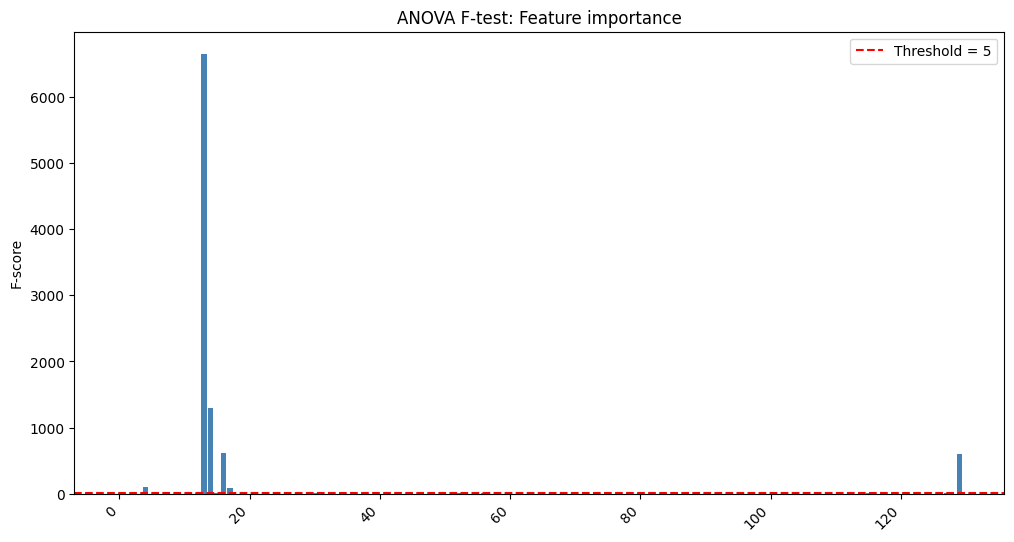

In [31]:
F_values, p_values = f_classif(df_processed, y_train)
anova_df = pd.DataFrame({
    'feature': df_processed.columns,
    'F_score': F_values,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)

print(anova_df)

# Threshold pre vizualizáciu (napr. F_score > 5 ako orientačné)
threshold = 5
colors = ['steelblue' if f > threshold else 'gray' for f in anova_df['F_score']]


# Vykreslenie
plt.figure(figsize=(12,6))
plt.bar(anova_df['feature'], anova_df['F_score'], color=colors)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F-score')
plt.title('ANOVA F-test: Feature importance')
plt.legend()
plt.show()

To see smaller values more clearly, we can cut the most significant outliers

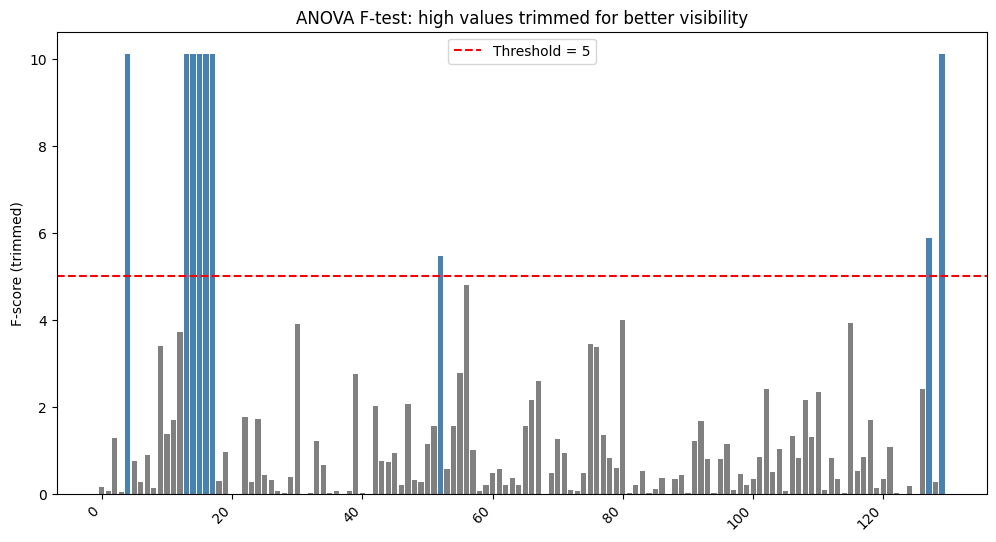

In [46]:
max_display = np.percentile(anova_df['F_score'], 95)  
plt.figure(figsize=(12,6))
plt.bar(anova_df['feature'], np.clip(anova_df['F_score'], 0, max_display), color=colors)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('F-score (trimmed)')
plt.title('ANOVA F-test: high values trimmed for better visibility')
plt.legend()
plt.show()

In the chart, around 20 features exceed the threshold of F-score = 5, indicating potential relevance. Two features stand out as strong outliers with exceptionally high F-scores, suggesting they may be key drivers in the model. We can see that index 13 and 14 are overly significant compared to other features as well as in mutual information implying there must be a patern and these features are really important 

Since the F-test is sensitive primarily to linear relationships, it is often beneficial to complement it with methods like Mutual Information, which can capture non-linear dependencies.

In [71]:
combined_df = pd.DataFrame({
    #'Variance': variances,
    'Mutual_Info': mi_series,
    'ANOVA_F': anova_df.set_index('feature')['F_score'],
    'ANOVA_p': anova_df.set_index('feature')['p_value']
})


combined_df = combined_df.sort_values(by='ANOVA_F', ascending=False)

print(combined_df.head(20))

     Mutual_Info      ANOVA_F        ANOVA_p
13      0.281499  6650.076029   0.000000e+00
14      0.131949  1299.259127  8.801890e-265
16      0.051769   611.738905  1.883535e-130
129     0.029480   593.177456  1.105261e-126
4       0.010960   107.712001   4.396355e-25
17      0.039111    86.609932   1.656254e-20
15      0.027422    13.580596   2.299654e-04
127     0.002224     5.879556   1.533851e-02
52      0.002088     5.456147   1.952287e-02
56      0.000000     4.807572   2.836212e-02
80      0.000000     3.999311   4.555082e-02
115     0.001889     3.916937   4.783430e-02
30      0.000000     3.899543   4.833175e-02
12      0.000713     3.722188   5.372742e-02
75      0.015402     3.445755   6.344924e-02
9       0.002358     3.407284   6.494416e-02
76      0.000438     3.371773   6.635746e-02
55      0.006563     2.765521   9.635243e-02
39      0.003804     2.750959   9.723322e-02
67      0.004884     2.596186   1.071586e-01


In [50]:
mi_thresh = 0.01
anova_thresh = 5   # and p < 0.05

# Binary selection flags
combined_df['Selected_MI'] = combined_df['Mutual_Info'] > mi_thresh
combined_df['Selected_ANOVA'] = (combined_df['ANOVA_F'] > anova_thresh) & (combined_df['ANOVA_p'] < 0.05)

# Count how many methods selected each feature (0, 1, or 2)
combined_df['Total_Selected'] = combined_df[['Selected_MI', 'Selected_ANOVA']].sum(axis=1)

# Sort by relevance score
combined_df = combined_df.sort_values(by='Total_Selected', ascending=False)

# Final selected features: selected by BOTH tests
final_features = combined_df.head(20).index
print(f"Number of selected features: {len(final_features)}")
print(final_features)


Number of selected features: 20
Index([ 13,  14,  16, 129,   4,  17,  15, 127,  52, 110,  92,  65, 118,  10,
        71,   7,  89, 116,  35,  38],
      dtype='int64')


We evaluated feature relevance using two independent statistical methods: Mutual Information and ANOVA. Each feature received a binary indicator reflecting whether it passed the threshold for a given method. Only a small subset of 7 features was selected by both methods.

# Wrappers

The wrapper methods are efective selector to examine what features we are going to select. It is probably the most precise technique to select given features. To do it, the concrete data model need to be constructed. 

In [58]:
model = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(model, n_features_to_select=20)
X_wrapper = rfe.fit_transform(df_processed, y_train)


In [62]:
selected_features_wrapper = df_processed.columns[rfe.support_]
print("Selected features (wrapper):", list(selected_features_wrapper))

Selected features (wrapper): [13, 14, 16, 28, 31, 34, 41, 67, 69, 71, 74, 75, 79, 101, 103, 108, 117, 118, 119, 129]


However, this method can be time-consuming with large datasets or a high number of features, since it needs to fit the model multiple times for different feature subsets. There is also a risk 

## Embedded methods

The embedded method combines the advantages of both filter and wrapper approaches. It performs feature selection during the model training process itself, meaning that the algorithm automatically identifies and assigns importance to the most relevant features while fitting the data. This makes it generally faster and less computationally expensive than wrapper methods, while still maintaining strong predictive power. Examples of embedded methods include models that provide feature importance scores, such as Lasso regression or tree-based algorithms like Random Forest.

In [63]:
sfm = SelectFromModel(model, max_features=20)  
sfm.fit(df_processed, y_train)
selected_features_embedded = df_processed.columns[sfm.get_support()]
print("Selected features(embedded):", list(selected_features_embedded))

Selected features(embedded): [13, 14, 16, 28, 31, 34, 41, 61, 67, 71, 74, 75, 79, 83, 101, 103, 117, 118, 119, 129]


The result is very similar to the wrapper method, indicating that both approaches consistently identified the same features as the most relevant for the model.

# Summary


🔗 Combined summary (top 30):


,Mutual_Info,ANOVA_F,ANOVA_p,Selected_MI,Selected_ANOVA,Selected_Wrapper,Selected_Embedded,Total_Selected
13,0.281499,6650.076029,0.000000e+00,True,True,True,True,4
14,0.131949,1299.259127,8.801890e-265,True,True,True,True,4
16,0.051769,611.738905,1.883535e-130,True,True,True,True,4
129,0.029480,593.177456,1.105261e-126,True,True,True,True,4
75,0.015402,3.445755,6.344924e-02,True,False,True,True,3
28,0.024480,0.023368,8.785083e-01,True,False,True,True,3
4,0.010960,107.712001,4.396355e-25,True,True,False,False,2
17,0.039111,86.609932,1.656254e-20,True,True,False,False,2
15,0.027422,13.580596,2.299654e-04,True,True,False,False,2
67,0.004884,2.596186,1.071586e-01,False,False,True,True,2



Union of top-20 features from all methods (count = 47):
[4, 7, 9, 10, 12, 13, 14, 15, 16, 17, 28, 30, 31, 34, 36, 39, 41, 44, 52, 55, 56, 60, 61, 66, 67, 69, 71, 72, 74, 75, 76, 79, 80, 83, 90, 92, 101, 103, 108, 114, 115, 117, 118, 119, 122, 127, 129]


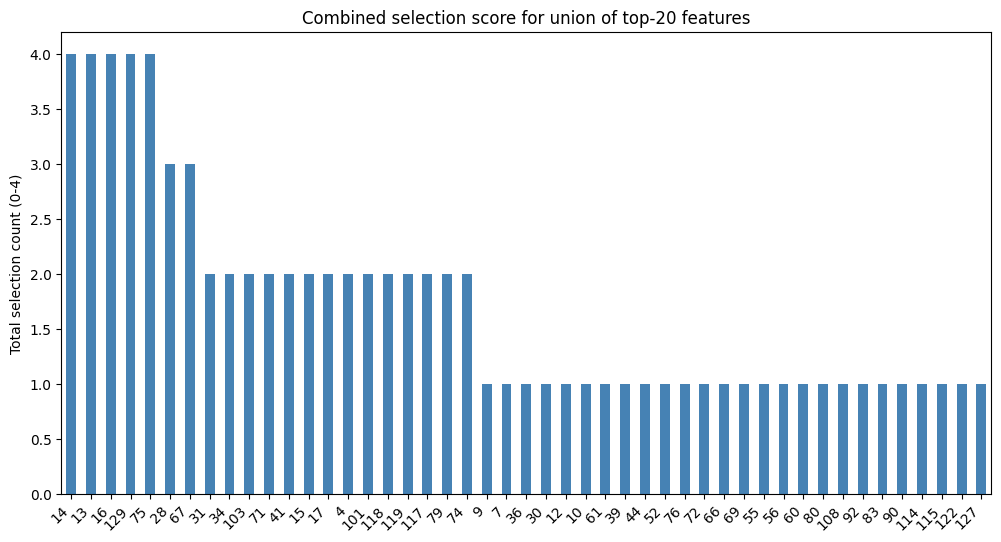

In [76]:
selected_features_wrapper = df_processed.columns[rfe.support_]
selected_features_embedded = df_processed.columns[sfm.get_support_() if hasattr(sfm, 'get_support_') else sfm.get_support()]

mi_thresh = 0.01
anova_thresh = 5
alpha = 0.05

combined_df['Selected_MI'] = combined_df['Mutual_Info'] > mi_thresh
combined_df['Selected_ANOVA'] = (combined_df['ANOVA_F'] > anova_thresh) & (combined_df['ANOVA_p'] < alpha)
combined_df['Selected_Wrapper'] = combined_df.index.isin(selected_features_wrapper)
combined_df['Selected_Embedded'] = combined_df.index.isin(selected_features_embedded)


combined_df['Total_Selected'] = combined_df[['Selected_MI', 'Selected_ANOVA', 'Selected_Wrapper', 'Selected_Embedded']].sum(axis=1)


combined_df_sorted = combined_df.sort_values(by=['Total_Selected', 'ANOVA_F', 'Mutual_Info'], ascending=[False, False, False])

print("\n🔗 Combined summary (top 30):")
display(combined_df_sorted.head(30))

top_mi = mi_series.sort_values(ascending=False).head(20).index
top_anova = anova_df.sort_values(by='F_score', ascending=False).head(20)['feature']
top_wrapper = selected_features_wrapper
top_embedded = selected_features_embedded

all_top_20 = sorted(set(top_mi) | set(top_anova) | set(top_wrapper) | set(top_embedded))
print("\nUnion of top-20 features from all methods (count = {}):".format(len(all_top_20)))
print(all_top_20)

summary_df = pd.DataFrame(index=all_top_20)
summary_df['Mutual_Info'] = summary_df.index.isin(top_mi)
summary_df['ANOVA_F'] = summary_df.index.isin(top_anova)
summary_df['Wrapper'] = summary_df.index.isin(top_wrapper)
summary_df['Embedded'] = summary_df.index.isin(top_embedded)
summary_df['Total_Selected'] = summary_df.sum(axis=1)
summary_df = summary_df.sort_values(by='Total_Selected', ascending=False)


# 9) Bar chart: počet "hlasov" pre každý feature
plt.figure(figsize=(12,6))
summary_df['Total_Selected'].plot(kind='bar', color='steelblue')
plt.ylabel('Total selection count (0-4)')
plt.title('Combined selection score for union of top-20 features')
plt.xticks(rotation=45, ha='right')
plt.show()

